<a href="https://colab.research.google.com/github/shivampatle2004/Machine-Learning-/blob/main/XGBoost_Ansh_CS23185.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [5]:
import pandas as pd

In [6]:
path="/content/drive/MyDrive/ML/BreastCancer.csv"
data=pd.read_csv(path)

In [7]:
print(data.head())
print(data.shape)

         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  texture_worst  perimeter_worst  area_worst  smoothness

In [8]:
print(data.info())
print(data.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [9]:
data = data.drop(['id', 'Unnamed: 32'], axis=1)

In [10]:
data['diagnosis'] = data['diagnosis'].map({'M':1, 'B':0})

In [11]:
X = data.drop('diagnosis', axis=1)
y = data['diagnosis']

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from xgboost import XGBClassifier


XGBoost Split: 80-20
Accuracy: 0.9561
Precision: 0.9524
Recall: 0.9302
F1-Score: 0.9412


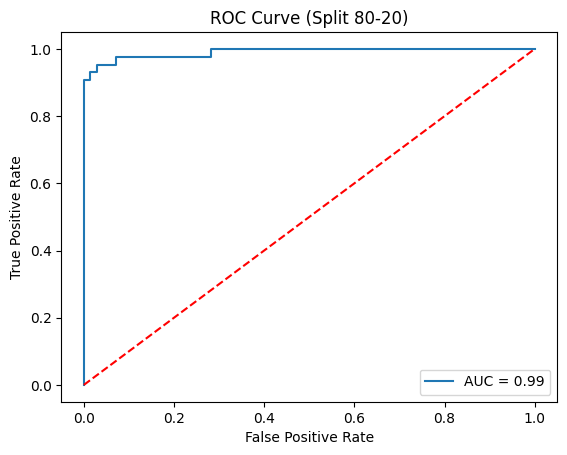


XGBoost Split: 70-30
Accuracy: 0.9649
Precision: 0.9385
Recall: 0.9683
F1-Score: 0.9531


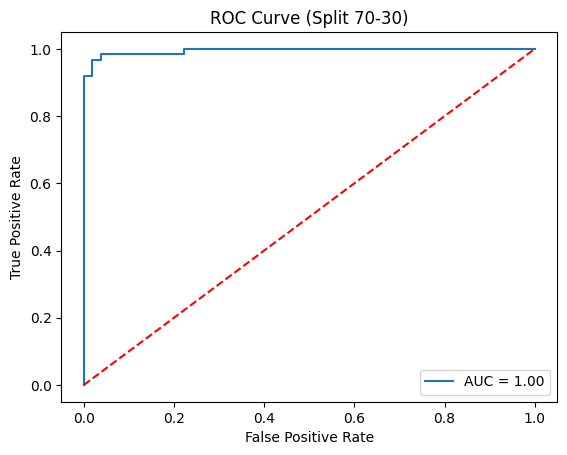

In [13]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_curve, roc_auc_score

for split in [0.2, 0.3]:

    print("\n==============================")
    print(f"XGBoost Split: {int((1-split)*100)}-{int(split*100)}")
    print("==============================")

    # Split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=split, random_state=42
    )

    # Model
    xgb_model = XGBClassifier(
        eval_metric='logloss'
    )

    xgb_model.fit(X_train, y_train)

    # Prediction
    y_pred = xgb_model.predict(X_test)
    y_proba = xgb_model.predict_proba(X_test)[:, 1] # Probability of positive class

    # Calculate Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall: {rec:.4f}")
    print(f"F1-Score: {f1:.4f}")

    # ROC Curve
    fpr, tpr, thresholds = roc_curve(y_test, y_proba)
    auc_score = roc_auc_score(y_test, y_proba)

    plt.figure()
    plt.plot(fpr, tpr, label=f'AUC = {auc_score:.2f}')
    plt.plot([0, 1], [0, 1], 'r--')
    plt.title(f"ROC Curve (Split {int((1-split)*100)}-{int(split*100)})")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend(loc="lower right")
    plt.show()

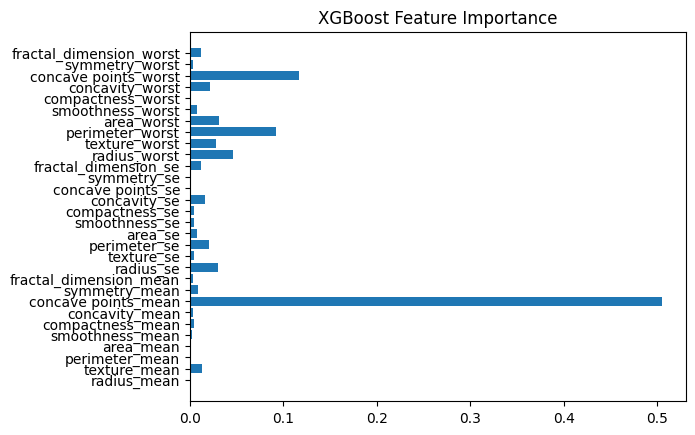

In [14]:
importance = xgb_model.feature_importances_

plt.figure()
plt.barh(X.columns, importance)
plt.title("XGBoost Feature Importance")
plt.show()